# Statistical Learning Theory
### Section 2 — PAC Learning & VC Dimensions

> **References:** Shalev-Shwartz & Ben-David – *Understanding Machine Learning* (Ch. 2–4) · Vapnik – *The Nature of Statistical Learning Theory* · Kearns & Vazirani – *An Introduction to Computational Learning Theory* · Lecture notes, SMIA Sapienza

**Goal:** Make the notion of "learning that generalizes" mathematically precise. We define when a hypothesis class is learnable, how many samples are needed, and how to measure the complexity of a hypothesis class — both for finite and infinite cases.

---

## Table of Contents
1. [PAC Learning — Consistent Learner (Realizable Case)](#1-pac-learning-consistent-learner-realizable-case)
2. [Agnostic PAC Learning — Inconsistent Learner](#2-agnostic-pac-learning-inconsistent-learner)
3. [VC Dimension](#3-vc-dimension)

---
# 1. PAC Learning — Consistent Learner (Realizable Case)

## 1.1 Setup and Motivation

In Section 1 we saw that ERM can overfit. The natural question is:

> *Under what precise conditions does ERM produce a hypothesis that generalizes? And how much data do we need?*

**PAC Learning** (Probably Approximately Correct — Valiant, 1984) gives a rigorous answer.

We work under the **realizable assumption**: there exists a true concept $c^* \in \mathcal{H}$ such that $y_i = c^*(x_i)$ for all training points — zero training error is achievable.

---

## 1.2 Formal Definition — PAC Learnability

**Definition (PAC Learnability):** A hypothesis class $\mathcal{H}$ is **PAC learnable** if there exists an algorithm $A$ and a function $m(\epsilon, \delta): (0,1)^2 \to \mathbb{N}$ such that for every $\epsilon, \delta \in (0,1)$, for every distribution $\mathcal{D}$ over $\mathcal{X}$, and for every target concept $c^* \in \mathcal{H}$:

$$
\forall\, m \geq m(\epsilon, \delta), \quad P_{S \sim \mathcal{D}^m}\left[R(h_S) \leq \epsilon\right] \geq 1 - \delta
$$

Reading the formula carefully:
- $\epsilon$ — **accuracy**: how close to optimal we want to be (small = more accurate)
- $\delta$ — **confidence**: probability of failure we can tolerate (small = more confident)
- $m(\epsilon, \delta)$ — **sample complexity**: the minimum number of samples needed
- The bound must hold for **any** distribution and **any** target in $\mathcal{H}$

The name says it all: with $m \geq m(\epsilon, \delta)$ samples, our learner is **probably** ($1-\delta$) **approximately correct** ($R \leq \epsilon$).

---

## 1.3 Sample Complexity — Definition

The **sample complexity** $m(\epsilon, \delta)$ is the minimum number of i.i.d. training examples sufficient to guarantee PAC learnability:

$$
\boxed{m(\epsilon, \delta) = \min\left\{ m \in \mathbb{N} \;:\; \forall\, \mathcal{D},\, c^* \in \mathcal{H},\; P\left[R(h_S) \leq \epsilon\right] \geq 1-\delta \right\}}
$$

Intuitively: $m(\epsilon, \delta)$ answers the question *"how much data is enough?"* as a function of how accurate and how confident we want to be.

A hypothesis class is **efficiently PAC learnable** if $m(\epsilon, \delta)$ is **polynomial** in $1/\epsilon$, $1/\delta$ — we do not need exponentially many samples.

## 1.4 Proof — Finite Hypothesis Class, Consistent Learner

**Theorem:** Let $\mathcal{H}$ be a finite hypothesis class and let $A$ be any consistent learner (i.e., $\hat{R}_S(h_S) = 0$). Then for any $\epsilon, \delta \in (0,1)$:

$$
P\left[R(h_S) > \epsilon\right] \leq |\mathcal{H}|\, e^{-\epsilon m}
$$

Setting this $\leq \delta$ and solving for $m$ gives:

$$
\boxed{m \geq \frac{1}{\epsilon}\left(\log|\mathcal{H}| + \log\frac{1}{\delta}\right)}
$$

---

### Proof sketch

**Step 1 — Define a bad hypothesis.**
Call $h \in \mathcal{H}$ **bad** if its true risk exceeds $\epsilon$:
$$h \text{ is bad} \iff R(h) > \epsilon$$
We want to show that $A$ is unlikely to output a bad hypothesis.

**Step 2 — Probability that a bad $h$ is consistent with $S$.**
If $R(h) > \epsilon$, then each training point $(x_i, y_i)$ is correctly classified by $h$ with probability at most $1 - \epsilon$ (since $h$ makes an error on at least a fraction $\epsilon$ of the distribution). Therefore:
$$P\left[\hat{R}_S(h) = 0 \;\middle|\; R(h) > \epsilon\right] \leq (1-\epsilon)^m \leq e^{-\epsilon m}$$

**Step 3 — Union bound over all bad hypotheses.**
There are at most $|\mathcal{H}|$ bad hypotheses. By the union bound:
$$P\left[\exists\, h \in \mathcal{H} : R(h) > \epsilon \text{ and } \hat{R}_S(h) = 0\right] \leq |\mathcal{H}|\, e^{-\epsilon m}$$

Since $A$ is consistent (it returns an $h$ with $\hat{R}_S = 0$), any bad $h$ it could return is covered by this bound.

**Step 4 — Solve for $m$.**
Set $|\mathcal{H}|\, e^{-\epsilon m} \leq \delta$:
$$e^{-\epsilon m} \leq \frac{\delta}{|\mathcal{H}|} \implies -\epsilon m \leq \log\frac{\delta}{|\mathcal{H}|} \implies m \geq \frac{1}{\epsilon}\log\frac{|\mathcal{H}|}{\delta}$$

which can be written as:
$$m \geq \frac{1}{\epsilon}\left(\log|\mathcal{H}| + \log\frac{1}{\delta}\right) \qquad \square$$

**Key observation:** The sample complexity grows **logarithmically** in $|\mathcal{H}|$ — even if we double the hypothesis class, we only need a handful of extra 

## 1.5 The Rectangle Learner — A Concrete Realization

The rectangle learner is one of the most elegant concrete examples of PAC learning. It makes the abstract machinery completely visual.

### Setup

- **Input space:** $\mathcal{X} = \mathbb{R}^2$
- **Output space:** $\mathcal{Y} = \{0, 1\}$ (positive / negative)
- **Hypothesis class:** $\mathcal{H} = $ all axis-aligned rectangles in $\mathbb{R}^2$
- **Target concept:** $c^* \in \mathcal{H}$ — the true (unknown) rectangle that labels points as positive

A point $x \in \mathbb{R}^2$ is labeled $+1$ if it falls inside $c^*$, and $-1$ otherwise.

### The Tightest Fit Algorithm

The consistent learner for this class is the **tightest fit** (smallest enclosing rectangle):

$$h_S = \text{smallest rectangle containing all positive training points}$$

This is the key idea: we want a generic hypothesis $h \in \mathcal{H}$ to **coincide** as closely as possible with the concept space $c^*$. The tightest fit is our best approximation of $c^*$ from the observed positive points — it is always a subset of $c^*$ (consistent, since it makes no false positives on the training set).

### Probabilistic Analysis

The error region of $h_S$ consists of four **strips** between $h_S$ and $c^*$ (one per side). The risk is:
$$R(h_S) = P_{x \sim \mathcal{D}}[x \in c^* \setminus h_S]$$

Each strip has probability at most $\epsilon/4$ after $m \geq \frac{4}{\epsilon}\log\frac{4}{\delta}$ samples — giving total risk $\leq \epsilon$ with probability $\geq 1-\delta$.

This is **polynomial** in $1/\epsilon$ and $1/\delta$ — the rectangle class is efficiently PAC learnable.

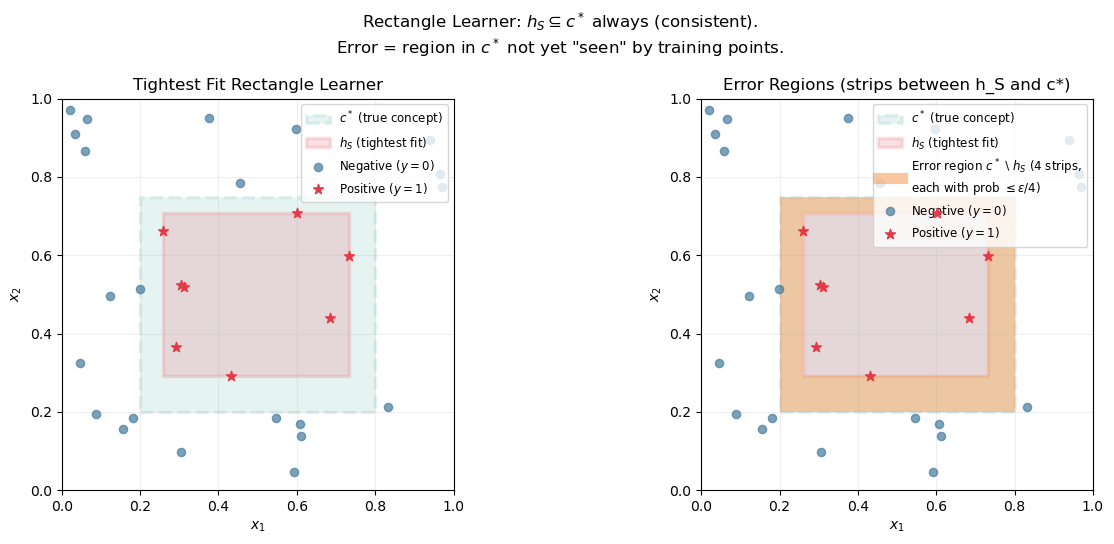

=== Rectangle Learner — Sample Complexity ===
  ε=0.10, δ=0.10  →  m ≥ 148 samples
  ε=0.10, δ=0.05  →  m ≥ 176 samples
  ε=0.05, δ=0.10  →  m ≥ 296 samples
  ε=0.05, δ=0.05  →  m ≥ 351 samples
  ε=0.01, δ=0.10  →  m ≥ 1476 samples
  ε=0.01, δ=0.05  →  m ≥ 1753 samples


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

np.random.seed(42)

# --- Ground truth rectangle c* ---
c_star = dict(x0=0.2, y0=0.2, x1=0.8, y1=0.75)

def inside(pts, rect):
    return ((pts[:,0] >= rect['x0']) & (pts[:,0] <= rect['x1']) &
            (pts[:,1] >= rect['y0']) & (pts[:,1] <= rect['y1']))

# Generate training points
n_train = 30
X = np.random.uniform(0, 1, (n_train, 2))
y = inside(X, c_star).astype(int)

pos = X[y == 1]
neg = X[y == 0]

# Tightest fit: smallest enclosing rectangle around positive points
h_S = dict(
    x0=pos[:,0].min(), y0=pos[:,1].min(),
    x1=pos[:,0].max(), y1=pos[:,1].max()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, title, show_strips in zip(
    axes,
    ['Tightest Fit Rectangle Learner', 'Error Regions (strips between h_S and c*)'],
    [False, True]
):
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.2)

    # Ground truth c*
    rect_cstar = patches.Rectangle(
        (c_star['x0'], c_star['y0']),
        c_star['x1'] - c_star['x0'],
        c_star['y1'] - c_star['y0'],
        linewidth=2.5, edgecolor='#2A9D8F', facecolor='#2A9D8F', alpha=0.12,
        linestyle='--', label='$c^*$ (true concept)'
    )
    ax.add_patch(rect_cstar)

    # Tightest fit h_S
    rect_hS = patches.Rectangle(
        (h_S['x0'], h_S['y0']),
        h_S['x1'] - h_S['x0'],
        h_S['y1'] - h_S['y0'],
        linewidth=2.5, edgecolor='#E63946', facecolor='#E63946', alpha=0.15,
        label='$h_S$ (tightest fit)'
    )
    ax.add_patch(rect_hS)

    if show_strips:
        # Four error strips: c* \ h_S
        strips = [
            # (x0, y0, width, height, label)
            (c_star['x0'], c_star['y0'], c_star['x1']-c_star['x0'], h_S['y0']-c_star['y0'], 'Bottom strip'),
            (c_star['x0'], h_S['y1'],   c_star['x1']-c_star['x0'], c_star['y1']-h_S['y1'], 'Top strip'),
            (c_star['x0'], h_S['y0'],   h_S['x0']-c_star['x0'],    h_S['y1']-h_S['y0'],   'Left strip'),
            (h_S['x1'],   h_S['y0'],   c_star['x1']-h_S['x1'],    h_S['y1']-h_S['y0'],   'Right strip'),
        ]
        for i, (sx, sy, sw, sh, slabel) in enumerate(strips):
            if sw > 0 and sh > 0:
                strip = patches.Rectangle((sx, sy), sw, sh,
                    facecolor='#F4A261', alpha=0.55, edgecolor='#F4A261', linewidth=0)
                ax.add_patch(strip)
        ax.plot([], [], color='#F4A261', linewidth=8, alpha=0.6,
                label='Error region $c^* \\setminus h_S$ (4 strips,\neach with prob $\\leq \\epsilon/4$)')

    # Data points
    ax.scatter(neg[:,0], neg[:,1], c='#457B9D', s=35, zorder=5, label='Negative ($y=0$)', alpha=0.7)
    ax.scatter(pos[:,0], pos[:,1], c='#E63946', s=55, marker='*', zorder=6, label='Positive ($y=1$)')

    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=8.5, loc='upper right')
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

plt.suptitle(
    'Rectangle Learner: $h_S \\subseteq c^*$ always (consistent).\n'
    'Error = region in $c^*$ not yet "seen" by training points.',
    fontsize=12
)
plt.tight_layout()
plt.show()

# Sample complexity for rectangle learner
print("=== Rectangle Learner — Sample Complexity ===")
for eps in [0.1, 0.05, 0.01]:
    for delta in [0.1, 0.05]:
        m = int(np.ceil((4 / eps) * np.log(4 / delta)))
        print(f"  ε={eps:.2f}, δ={delta:.2f}  →  m ≥ {m} samples")

## 1.6 Numerical Simulation: The Rectangle Learner & The Union Bound

To mathematically evaluate the generalization performance of the Empirical Risk Minimization (ERM) algorithm within a realizable geometric setting, we consider the class of axis-aligned rectangles in $\mathbb{R}^2$. Let $R^*$ denote the true underlying target concept, and let $h_S$ be the empirical hypothesis constructed from a sample $S$ of size $m$, sampled independently and identically distributed ($i.i.d.$) from a continuous probability distribution $\mathcal{D}$.

By definition of the ERM for the realizable case, $h_S$ is the tightest bounding box enclosing all positive samples. Thus, $h_S \subseteq R^*$, meaning the generalization error risk $R(h_S)$ corresponds exactly to the probability mass of the region difference:

$$R(h_S) = \mathbb{P}_{x \sim \mathcal{D}} (x \in R^* \setminus h_S)$$

### The Four-Strip Partitioning Argument

To derive a structural bound on the tail probability $\mathbb{P}(R(h_S) > \epsilon)$, we partition the boundary gap into four directional internal strips along the edges of $R^*$, denoted as $E_N, E_S, E_E$, and $E_W$ (representing North, South, East, and West, respectively).

If the total generalization error exceeds our tolerance threshold, i.e., $R(h_S) > \epsilon$, it geometrically implies that the hypothesis $h_S$ must completely miss at least one of these four strategic zones. By construction, we set the probability mass of each individual strip to be exactly $\frac{\epsilon}{4}$:

$$\mathbb{P}(E_N) = \mathbb{P}(E_S) = \mathbb{P}(E_E) = \mathbb{P}(E_W) = \frac{\epsilon}{4}$$

### Probabilistic Bound via Boole's Inequality

The event of failing to generalize can be expressed as a subset of the union of missing any single strip. Applying Boole's inequality (commonly referred to as the **Union Bound**), we decouple the joint probability of failure into the sum of individual failure probabilities:

$$
\begin{aligned}
\mathbb{P}\Big( R(h_S) > \epsilon \Big) &\le \mathbb{P}\left( \bigcup_{i \in \{N,S,E,W\}} \{h_S \cap E_i = \emptyset\} \right) \\
&\le \sum_{i \in \{N,S,E,W\}} \mathbb{P}\big(h_S \cap E_i = \emptyset\big)
\end{aligned}
$$

Since the $m$ data points are drawn $i.i.d.$, the probability that all $m$ training samples fall entirely outside a specific strip of mass $\frac{\epsilon}{4}$ decays geometrically:

$$\mathbb{P}\big(h_S \cap E_i = \emptyset\big) = \left(1 - \frac{\epsilon}{4}\right)^m$$

Substituting this back into the Union Bound formulation, and utilizing the fundamental analytical inequality $1 - x \le e^{-x}$ (valid $\forall x \in \mathbb{R}$), we arrive at the standard PAC distribution-free sample complexity bound:

$$\mathbb{P}\Big( R(h_S) > \epsilon \Big) \le 4 \left(1 - \frac{\epsilon}{4}\right)^m \le 4e^{-\frac{m\epsilon}{4}}$$

Setting this upper bound less than or equal to our confidence parameter $\delta$ yields the classical logarithmic sample complexity requirement for axis-aligned rectangles:

$$m \ge \frac{4}{\epsilon} \ln\left(\frac{4}{\delta}\right)$$

---
### NumPy Numerical Verification

We can numerical verify this theoretical upper bound by evaluating the indicator function over a large-scale test partition via Monte Carlo integration, measuring the empirical mismatch fraction where the ERM hypothesis disagrees with the target.

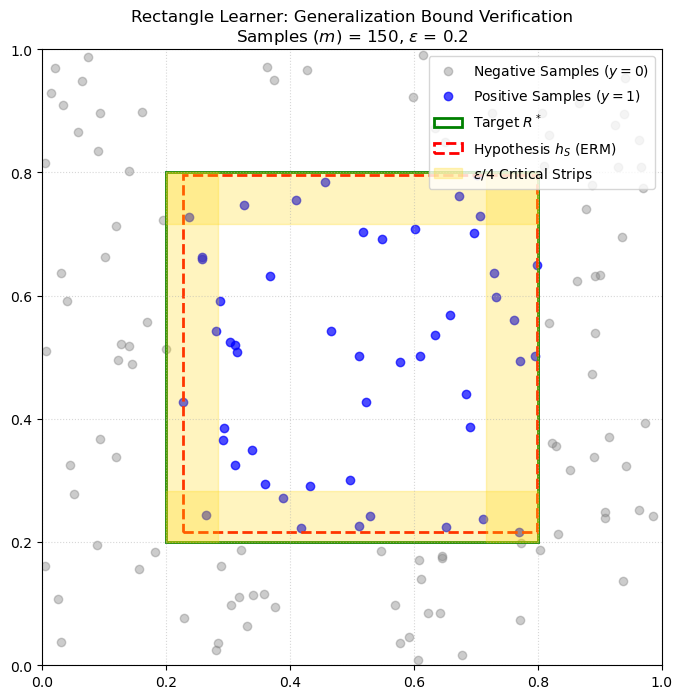

 SIMULATION RESULTS
-> True Generalization Error R(h_S): 0.0296
-> PAC Error Bound Condition (R(h_S) <= epsilon) met? True


In [2]:


import numpy as np
import matplotlib.pyplot as plt

# 1. Parameter setup (independent and identically distributed sampling)
np.random.seed(42)
m = 150              # Number of training samples
epsilon = 0.2        # Maximum tolerated generalization error
delta = 0.05         # Tail bound failure probability tolerance

# Define the true underlying target concept R* [x_min, x_max, y_min, y_max]
R_true = np.array([0.2, 0.8, 0.2, 0.8])

# 2. Sample data uniformly from the domain [0, 1]²
X = np.random.uniform(0, 1, (m, 2))

# Realizable labeling function (c*(x) = 1 if inside R*, 0 otherwise)
inside_X = (X[:, 0] >= R_true[0]) & (X[:, 0] <= R_true[1])
inside_Y = (X[:, 1] >= R_true[2]) & (X[:, 1] <= R_true[3])
Y = (inside_X & inside_Y).astype(int)

# 3. ERM Algorithm for Rectangles: find the tightest bounding box over positive points
X_positive = X[Y == 1]
if len(X_positive) > 0:
    h_S = np.array([
        np.min(X_positive[:, 0]), # Empirical x_min
        np.max(X_positive[:, 0]), # Empirical x_max
        np.min(X_positive[:, 1]), # Empirical y_min
        np.max(X_positive[:, 1])  # Empirical y_max
    ])
else:
    h_S = np.array([0, 0, 0, 0])

# 4. Geometry of the epsilon/4 strips
# Under a uniform distribution, the probability mass scales linearly with the area.
# To ensure each strip has a probability mass of exactly epsilon/4:
width = R_true[1] - R_true[0]
height = R_true[3] - R_true[2]

strip_w = (epsilon / 4) / height  # Width of West/East strips
strip_h = (epsilon / 4) / width   # Height of North/South strips

# 5. Visualizing the geometric argument of the Union Bound
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Plot training samples
ax.scatter(X[Y==0, 0], X[Y==0, 1], c='gray', alpha=0.4, label='Negative Samples ($y=0$)')
ax.scatter(X[Y==1, 0], X[Y==1, 1], c='blue', alpha=0.7, label='Positive Samples ($y=1$)')

# Draw Ground Truth R*
rect_true = plt.Rectangle((R_true[0], R_true[2]), width, height, 
                          edgecolor='green', fill=False, linewidth=2, label='Target $R^*$')
ax.add_patch(rect_true)

# Draw ERM Hypothesis h_S
rect_hS = plt.Rectangle((h_S[0], h_S[2]), h_S[1]-h_S[0], h_S[3]-h_S[2], 
                         edgecolor='red', fill=False, linewidth=2, linestyle='--', label='Hypothesis $h_S$ (ERM)')
ax.add_patch(rect_hS)

# Overlay the 4 critical epsilon/4 strips inside R*
# West strip
ax.add_patch(plt.Rectangle((R_true[0], R_true[2]), strip_w, height, color='gold', alpha=0.25, label='$\\epsilon/4$ Critical Strips'))
# East strip
ax.add_patch(plt.Rectangle((R_true[1] - strip_w, R_true[2]), strip_w, height, color='gold', alpha=0.25))
# South strip
ax.add_patch(plt.Rectangle((R_true[0], R_true[2]), width, strip_h, color='gold', alpha=0.25))
# North strip
ax.add_patch(plt.Rectangle((R_true[0], R_true[3] - strip_h), width, strip_h, color='gold', alpha=0.25))

ax.set_title(f"Rectangle Learner: Generalization Bound Verification\nSamples ($m$) = {m}, $\\epsilon$ = {epsilon}", fontsize=12)
ax.legend(loc='upper right', frameon=True)
ax.grid(True, linestyle=':', alpha=0.5)
plt.show()

# 6. Empirical Generalization Error via Monte Carlo Approximation
X_large = np.random.uniform(0, 1, (100000, 2))
in_R = (X_large[:, 0] >= R_true[0]) & (X_large[:, 0] <= R_true[1]) & (X_large[:, 1] >= R_true[2]) & (X_large[:, 1] <= R_true[3])
in_h = (X_large[:, 0] >= h_S[0]) & (X_large[:, 0] <= h_S[1]) & (X_large[:, 1] >= h_S[2]) & (X_large[:, 1] <= h_S[3])

# Generalization error is the probability mass where the hypothesis disagrees with the target
true_error = np.mean(in_R != in_h)

print("="*50)
print(" SIMULATION RESULTS")
print("="*50)
print(f"-> True Generalization Error R(h_S): {true_error:.4f}")
print(f"-> PAC Error Bound Condition (R(h_S) <= epsilon) met? {true_error <= epsilon}")
print("="*50)

## 2.1 Beyond the Realizable Assumption

The consistent PAC framework assumed $c^* \in \mathcal{H}$ — the true concept is in our hypothesis class, so we can achieve zero training error. This is rarely true in practice:

- Labels may be **noisy** — same $x$ can have different $y$ in different draws
- $\mathcal{H}$ may be **too simple** to capture $c^*$ exactly
- The data generating process may be **fundamentally stochastic**

**Agnostic PAC learning** drops the realizable assumption entirely. We make no assumption about $\mathcal{D}$ or whether $c^* \in \mathcal{H}$. The best we can hope for is to compete with the **best hypothesis in $\mathcal{H}$**:

$$h_S \text{ should satisfy} \quad R(h_S) \leq \min_{h \in \mathcal{H}} R(h) + \epsilon$$

---

## 2.2 Remark — From LLN to Hoeffding: A Quantitative Leap

The **Law of Large Numbers** (LLN) tells us that for any fixed $h$:
$$\hat{R}_S(h) \xrightarrow{m \to \infty} R(h) \quad \text{almost surely}$$

This is an **asymptotic** statement — it says convergence happens eventually, but gives no information about *how fast* or *how many samples* are needed for a given accuracy.

**Hoeffding's inequality** is the quantitative, non-asymptotic version. For bounded random variables $Z_i \in [a, b]$ with $\hat{Z} = \frac{1}{m}\sum Z_i$:

$$
\boxed{P\left[|\hat{Z} - \mathbb{E}[Z]| \geq t\right] \leq 2\exp\left(-\frac{2m^2 t^2}{\sum_i (b_i - a_i)^2}\right)}
$$

Applied to the loss (with $\ell \in [0,1]$, so $b-a=1$):

$$
P\left[|\hat{R}_S(h) - R(h)| \geq t\right] \leq 2e^{-2mt^2}
$$

This is the engine of agnostic PAC learning: Hoeffding gives us **exact finite-sample guarantees** about how close empirical risk is to true risk — something LLN alone cannot provide.

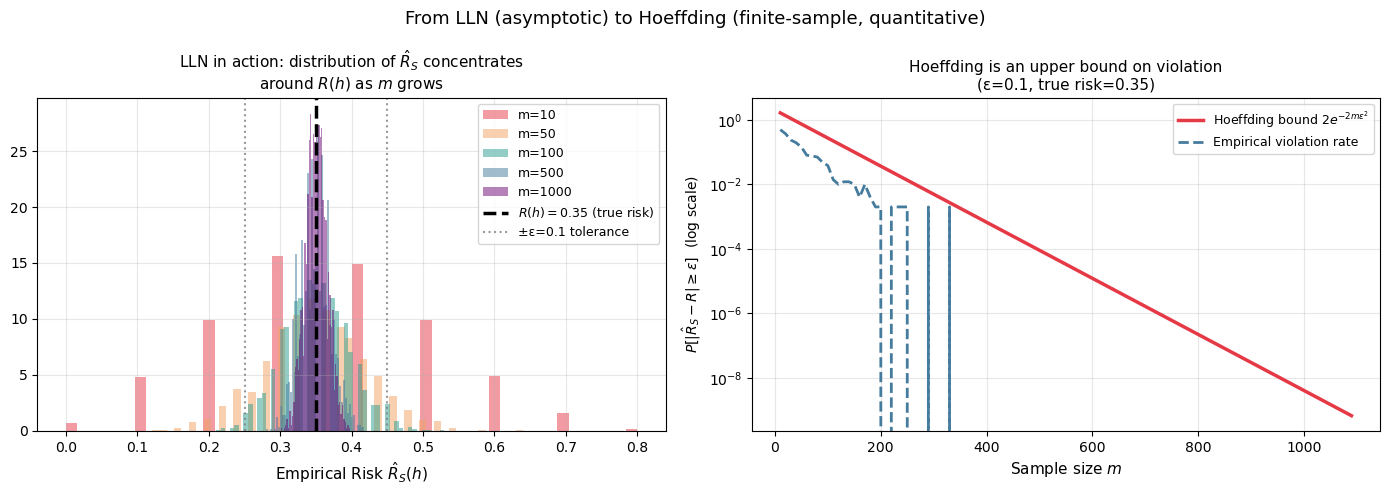

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# True risk of a fixed hypothesis (unknown to learner)
R_true = 0.35
n_experiments = 2000
sample_sizes = [10, 50, 100, 500, 1000]
t = 0.10   # tolerance

empirical_means = {m: [] for m in sample_sizes}
for m in sample_sizes:
    for _ in range(n_experiments):
        losses = (np.random.rand(m) < R_true).astype(float)
        empirical_means[m].append(losses.mean())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: distribution of empirical risk for different m ---
ax = axes[0]
colors = ['#E63946','#F4A261','#2A9D8F','#457B9D','#6A0572']
for m, color in zip(sample_sizes, colors):
    ax.hist(empirical_means[m], bins=50, density=True, alpha=0.5,
            color=color, label=f'm={m}')
ax.axvline(R_true, color='black', lw=2.5, linestyle='--', label=f'$R(h)={R_true}$ (true risk)')
ax.axvline(R_true - t, color='gray', lw=1.5, linestyle=':', alpha=0.8)
ax.axvline(R_true + t, color='gray', lw=1.5, linestyle=':', alpha=0.8,
           label=f'±ε={t} tolerance')
ax.set_xlabel('Empirical Risk $\\hat{R}_S(h)$', fontsize=11)
ax.set_title('LLN in action: distribution of $\\hat{R}_S$ concentrates\naround $R(h)$ as $m$ grows', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# --- Right: Hoeffding bound vs empirical violation rate ---
ax2 = axes[1]
ms = np.arange(10, 1100, 10)
hoeffding_bound = 2 * np.exp(-2 * ms * t**2)

empirical_violation = []
for m in ms:
    violations = sum(
        abs((np.random.rand(m) < R_true).mean() - R_true) >= t
        for _ in range(500)
    ) / 500
    empirical_violation.append(violations)

ax2.semilogy(ms, hoeffding_bound, '#E63946', lw=2.5, label=f'Hoeffding bound $2e^{{-2m\\epsilon^2}}$')
ax2.semilogy(ms, empirical_violation, '#457B9D', lw=2, linestyle='--',
             label='Empirical violation rate')
ax2.set_xlabel('Sample size $m$', fontsize=11)
ax2.set_ylabel('$P[|\\hat{R}_S - R| \\geq \\epsilon]$  (log scale)', fontsize=10)
ax2.set_title(f'Hoeffding is an upper bound on violation\n(ε={t}, true risk={R_true})', fontsize=11)
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

plt.suptitle('From LLN (asymptotic) to Hoeffding (finite-sample, quantitative)', fontsize=13)
plt.tight_layout()
plt.show()

## 2.3 Proof — Agnostic PAC via Hoeffding Bound

**Goal:** Bound the probability that the ERM solution $h_S = \arg\min_{h \in \mathcal{H}} \hat{R}_S(h)$ has high true risk.

**Step 1 — Uniform convergence.**
We want $\hat{R}_S(h) \approx R(h)$ for **all** $h \in \mathcal{H}$ simultaneously. Apply Hoeffding to each $h$ and take a union bound over $\mathcal{H}$:

$$P\left[\exists\, h \in \mathcal{H} : |\hat{R}_S(h) - R(h)| > \frac{\epsilon}{2}\right] \leq 2|\mathcal{H}|\, e^{-2m(\epsilon/2)^2} = 2|\mathcal{H}|\, e^{-m\epsilon^2/2}$$

**Step 2 — Transfer the bound to ERM.**
On the event where uniform convergence holds (probability $\geq 1-\delta$), for $h_S = \arg\min \hat{R}_S$:

$$
R(h_S) \leq \hat{R}_S(h_S) + \frac{\epsilon}{2} \leq \hat{R}_S(h^*) + \frac{\epsilon}{2} \leq R(h^*) + \epsilon
$$

where $h^* = \arg\min_{h \in \mathcal{H}} R(h)$ is the best hypothesis in class.

**Step 3 — Solve for $m$.**
Set $2|\mathcal{H}|\, e^{-m\epsilon^2/2} \leq \delta$:

$$
\boxed{m \geq \frac{2}{\epsilon^2}\left(\log|\mathcal{H}| + \log\frac{2}{\delta}\right)}
$$

---

## 2.4 Consistent vs Agnostic — A Critical Comparison

| | **Consistent (Realizable)** | **Agnostic (Unrealizable)** |
|---|---|---|
| Assumption | $c^* \in \mathcal{H}$, zero train error | None — $c^*$ may not be in $\mathcal{H}$ |
| Tool | Union bound only | Hoeffding + Union bound |
| Sample complexity | $m \geq \dfrac{1}{\epsilon}\log\dfrac{|\mathcal{H}|}{\delta}$ | $m \geq \dfrac{2}{\epsilon^2}\log\dfrac{2|\mathcal{H}|}{\delta}$ |
| Dependence on $\epsilon$ | $\mathcal{O}(1/\epsilon)$ | $\mathcal{O}(1/\epsilon^2)$ |
| Guarantee | $R(h_S) \leq \epsilon$ | $R(h_S) \leq \min_h R(h) + \epsilon$ |

### ⚠️ Key message for the student

The dependence on $\epsilon$ changes from $1/\epsilon$ to $1/\epsilon^2$ — this is not a minor detail. To achieve the same accuracy $\epsilon$ with the same confidence $\delta$:

- Consistent learner needs $m \propto 1/\epsilon$ samples
- Agnostic learner needs $m \propto 1/\epsilon^2$ samples — **quadratically more**

For example, to go from $\epsilon = 0.1$ to $\epsilon = 0.01$:
- Consistent: $10\times$ more samples
- Agnostic: $100\times$ more samples

This gap reflects the fundamental difficulty of learning without assumptions: in the agnostic setting we must control the worst-case fluctuation of the empirical risk uniformly over $\mathcal{H}$, and Hoeffding's bound introduces a quadratic cost in $\epsilon$.

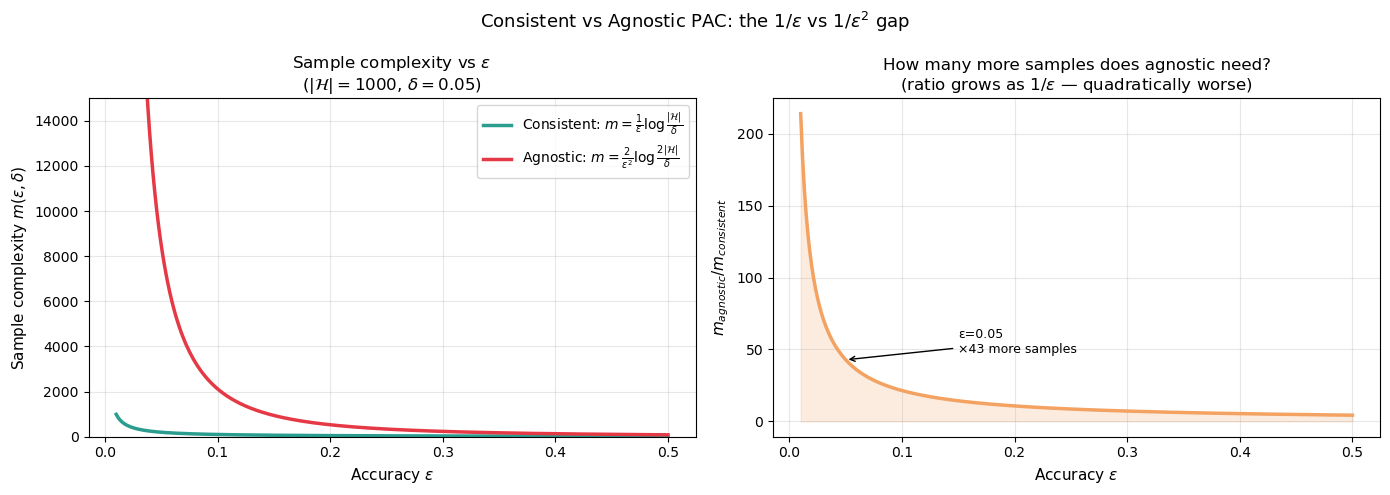

=== Numeric comparison: samples needed for same (ε, δ) ===
     ε |     Consistent |       Agnostic |    Ratio
--------------------------------------------------
  0.20 |             50 |            530 |    10.6x
  0.10 |            100 |          2,120 |    21.2x
  0.05 |            199 |          8,478 |    42.6x
  0.01 |            991 |        211,933 |   213.9x


In [4]:
import numpy as np
import matplotlib.pyplot as plt

H_size = 1000   # |H|
delta  = 0.05
epsilons = np.linspace(0.01, 0.5, 300)

m_consistent = (1 / epsilons) * np.log(H_size / delta)
m_agnostic   = (2 / epsilons**2) * np.log(2 * H_size / delta)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: sample complexity vs epsilon ---
ax = axes[0]
ax.plot(epsilons, m_consistent, '#2A9D8F', lw=2.5, label='Consistent: $m = \\frac{1}{\\epsilon}\\log\\frac{|\\mathcal{H}|}{\\delta}$')
ax.plot(epsilons, m_agnostic,   '#E63946', lw=2.5, label='Agnostic: $m = \\frac{2}{\\epsilon^2}\\log\\frac{2|\\mathcal{H}|}{\\delta}$')
ax.set_xlabel('Accuracy $\\epsilon$', fontsize=11)
ax.set_ylabel('Sample complexity $m(\\epsilon, \\delta)$', fontsize=11)
ax.set_ylim(0, 15000)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax.set_title(f'Sample complexity vs $\\epsilon$\n($|\\mathcal{{H}}|={H_size}$, $\\delta={delta}$)', fontsize=12)

# --- Right: ratio agnostic/consistent ---
ax2 = axes[1]
ratio = m_agnostic / m_consistent
ax2.plot(epsilons, ratio, '#F4A261', lw=2.5)
ax2.fill_between(epsilons, ratio, alpha=0.2, color='#F4A261')
ax2.set_xlabel('Accuracy $\\epsilon$', fontsize=11)
ax2.set_ylabel('$m_{agnostic} / m_{consistent}$', fontsize=11)
ax2.set_title('How many more samples does agnostic need?\n(ratio grows as $1/\\epsilon$ — quadratically worse)', fontsize=12)
ax2.grid(True, alpha=0.3)

# Annotate a specific point
eps_ex = 0.05
r_ex = (2 / eps_ex**2 * np.log(2*H_size/delta)) / (1/eps_ex * np.log(H_size/delta))
ax2.annotate(f'ε=0.05\n×{r_ex:.0f} more samples',
             xy=(eps_ex, r_ex), xytext=(0.15, r_ex+5),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=9)

plt.suptitle('Consistent vs Agnostic PAC: the $1/\\epsilon$ vs $1/\\epsilon^2$ gap', fontsize=13)
plt.tight_layout()
plt.show()

print("=== Numeric comparison: samples needed for same (ε, δ) ===")
print(f"{'ε':>6} | {'Consistent':>14} | {'Agnostic':>14} | {'Ratio':>8}")
print("-" * 50)
for eps in [0.20, 0.10, 0.05, 0.01]:
    mc = int(np.ceil((1/eps) * np.log(H_size/delta)))
    ma = int(np.ceil((2/eps**2) * np.log(2*H_size/delta)))
    print(f"  {eps:.2f} | {mc:>14,} | {ma:>14,} | {ma/mc:>7.1f}x")

---
# 3. VC Dimension

## 3.1 Why We Need a New Complexity Measure

Everything so far assumed $\mathcal{H}$ is **finite**. The sample complexity bounds involved $\log|\mathcal{H}|$ — a perfectly well-defined quantity.

But most hypothesis classes we care about are **infinite**:
- All linear classifiers in $\mathbb{R}^d$: $|\mathcal{H}| = \infty$
- All neural networks with given architecture: $|\mathcal{H}| = \infty$
- All axis-aligned rectangles in $\mathbb{R}^2$: $|\mathcal{H}| = \infty$

When $|\mathcal{H}| \to \infty$, the bounds $\frac{1}{\epsilon}\log|\mathcal{H}|$ and $\frac{2}{\epsilon^2}\log|\mathcal{H}|$ become meaningless.

> **We need a notion of complexity that works for infinite hypothesis classes.**

The **VC dimension** (Vapnik & Chervonenkis, 1971) is that notion. It measures complexity not by counting hypotheses, but by measuring how many points the class can **shatter** — classify in all possible ways.

---

## 3.2 Shattering

**Definition (Shattering):** A hypothesis class $\mathcal{H}$ **shatters** a set $C = \{x_1, \dots, x_m\} \subseteq \mathcal{X}$ if for every possible labeling $y \in \{0,1\}^m$ there exists $h \in \mathcal{H}$ such that:

$$h(x_i) = y_i \quad \forall\, i = 1, \dots, m$$

In other words: $\mathcal{H}$ shatters $C$ if it can realize **all $2^m$ possible labelings** of $C$.

Intuitively: shattering means the hypothesis class is expressive enough to perfectly separate any configuration of $m$ points — it has total flexibility on that set.

---

## 3.3 VC Dimension — Definition

**Definition (VC Dimension):** The **VC dimension** of a hypothesis class $\mathcal{H}$ is:

$$
\boxed{d_{\mathrm{VC}}(\mathcal{H}) = \max\left\{ m \in \mathbb{N} \;:\; \exists\, C \subseteq \mathcal{X},\, |C| = m,\, \mathcal{H} \text{ shatters } C \right\}}
$$

The VC dimension is the size of the **largest set** that $\mathcal{H}$ can shatter.

- If $\mathcal{H}$ can shatter some set of size $d$ but no set of size $d+1$, then $d_{\mathrm{VC}}(\mathcal{H}) = d$
- If $\mathcal{H}$ can shatter sets of arbitrarily large size: $d_{\mathrm{VC}}(\mathcal{H}) = \infty$

---

## 3.4 The $d+1$ Result — Linear Classifiers in $\mathbb{R}^d$

The most important classical result:

**Theorem:** The VC dimension of the class of linear classifiers (hyperplanes) in $\mathbb{R}^d$ is:
$$d_{\mathrm{VC}} = d + 1$$

**Why $d+1$?**
- Any $d+1$ points in **general position** in $\mathbb{R}^d$ can be shattered by a hyperplane → $d_{\mathrm{VC}} \geq d+1$
- No set of $d+2$ points can always be shattered (Radon's theorem) → $d_{\mathrm{VC}} \leq d+1$

**Crucial implication — dimensionality and complexity:**

The VC dimension grows **linearly with the number of features** $d$. More dimensions = richer class = harder to learn. The sample complexity of the agnostic case becomes:

$$m = \mathcal{O}\!\left(\frac{d + \log(1/\delta)}{\epsilon^2}\right)$$

Adding one feature dimension directly increases the required number of samples — this is the precise mathematical formulation of the **curse of dimensionality** from a learning-theoretic perspective.

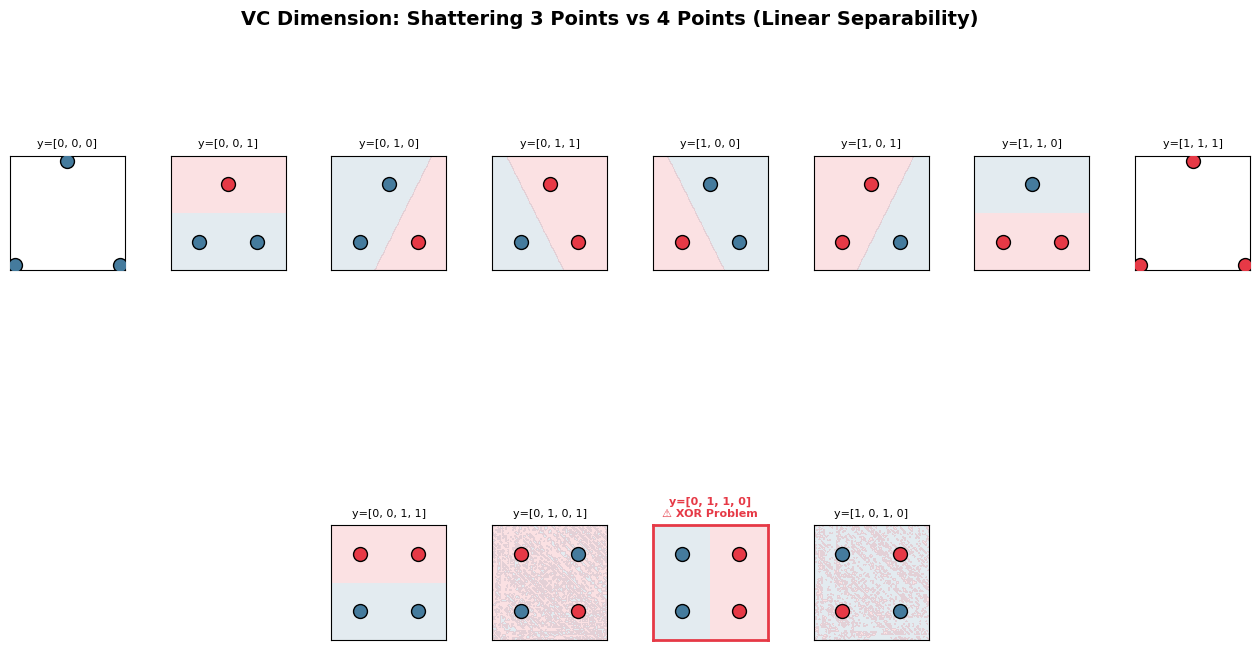

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
from sklearn.svm import SVC

# --- Data ---
pts3 = np.array([[0.2, 0.2], [0.8, 0.2], [0.5, 0.8]])
pts4 = np.array([[0.2, 0.2], [0.8, 0.2], [0.8, 0.8], [0.2, 0.8]])

all_labelings_3 = list(product([0, 1], repeat=3)) 
interesting_4 = [[0, 0, 1, 1], [0, 1, 0, 1], [0, 1, 1, 0], [1, 0, 1, 0]]

# --- GRID CONFIGURATION ---
# The grid MUST have 8 columns to properly accommodate the 8 plots in the first row.
fig = plt.figure(figsize=(16, 8))
gs = fig.add_gridspec(2, 8, hspace=0.5, wspace=0.4) 

colors_map = {0: '#457B9D', 1: '#E63946'}
x_grid = np.linspace(-0.1, 1.1, 100)
xx, yy = np.meshgrid(x_grid, x_grid)
grid_pts = np.c_[xx.ravel(), yy.ravel()]

# --- Row 1: 3 points (VC Dimension / Shattering evaluation, i from 0 to 7) ---
for i, labeling in enumerate(all_labelings_3):
    ax = fig.add_subplot(gs[0, i]) 
    y_arr = np.array(labeling)

    if len(np.unique(y_arr)) > 1:
        clf = SVC(kernel='linear', C=100).fit(pts3, y_arr)
        Z = clf.predict(grid_pts).reshape(xx.shape)
        ax.contourf(xx, yy, Z, alpha=0.15, colors=['#457B9D', '#E63946'], levels=[-0.5, 0.5, 1.5])

    for pt, lbl in zip(pts3, labeling):
        ax.scatter(*pt, s=100, color=colors_map[lbl], edgecolors='black', zorder=5)
    
    ax.set_title(f'y={list(labeling)}', fontsize=8)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect('equal')

# --- Row 2: 4 points (Showing that 4 points cannot be shattered, i from 0 to 3) ---
for i, labeling in enumerate(interesting_4):
    # Centering the 4 plots using columns 2 to 5 for a balanced layout
    ax = fig.add_subplot(gs[1, i + 2]) 
    y_arr = np.array(labeling)

    clf = SVC(kernel='linear', C=100).fit(pts4, y_arr)
    Z = clf.predict(grid_pts).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.15, colors=['#457B9D', '#E63946'], levels=[-0.5, 0.5, 1.5])

    for pt, lbl in zip(pts4, labeling):
        ax.scatter(*pt, s=100, color=colors_map[lbl], edgecolors='black', zorder=5)

    # Highlighting the non-linearable XOR error
    if labeling == [0, 1, 1, 0]:
        ax.set_title(f'y={labeling}\n⚠ XOR Problem', fontsize=8, color='#E63946', fontweight='bold')
        for spine in ax.spines.values():
            spine.set_edgecolor('#E63946')
            spine.set_linewidth(2)
    else:
        ax.set_title(f'y={labeling}', fontsize=8)

    ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect('equal')

plt.suptitle('VC Dimension: Shattering 3 Points vs 4 Points (Linear Separability)', fontsize=14, y=0.98, fontweight='bold')
plt.show()

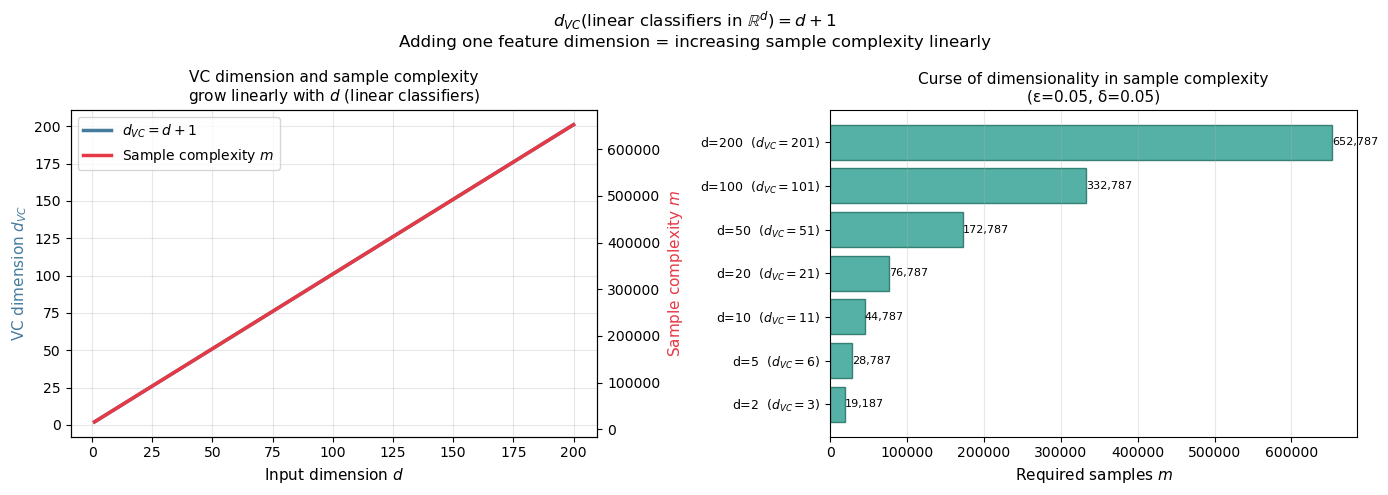

=== Sample complexity vs dimension (ε=0.05, δ=0.05) ===
    d |   d_VC |   m required
------------------------------
    2 |      3 |       19,187
    5 |      6 |       28,787
   10 |     11 |       44,787
   50 |     51 |      172,787
  100 |    101 |      332,787
  200 |    201 |      652,787


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# VC dimension of linear classifiers = d+1
# Sample complexity (agnostic) scales as O(d / epsilon^2)

dimensions = np.arange(1, 201)   # d from 1 to 200
vc_dims    = dimensions + 1      # d_VC = d + 1

epsilon = 0.05
delta   = 0.05

# Fundamental theorem of PAC learning (agnostic, VC-based):
# m = O( (d_VC + log(1/delta)) / epsilon^2 )
C = 8   # standard constant in the bound
m_vc = C * (vc_dims + np.log(1/delta)) / epsilon**2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: VC dim and sample complexity vs dimensionality
ax = axes[0]
ax2_twin = ax.twinx()
l1, = ax.plot(dimensions, vc_dims, '#457B9D', lw=2.5, label='$d_{VC} = d+1$')
l2, = ax2_twin.plot(dimensions, m_vc, '#E63946', lw=2.5, label='Sample complexity $m$')
ax.set_xlabel('Input dimension $d$', fontsize=11)
ax.set_ylabel('VC dimension $d_{VC}$', fontsize=11, color='#457B9D')
ax2_twin.set_ylabel('Sample complexity $m$', fontsize=11, color='#E63946')
ax.set_title('VC dimension and sample complexity\ngrow linearly with $d$ (linear classifiers)', fontsize=11)
lines = [l1, l2]
ax.legend(lines, [l.get_label() for l in lines], fontsize=10)
ax.grid(True, alpha=0.3)

# Right: concrete numbers
ax3 = axes[1]
ds_select = [2, 5, 10, 20, 50, 100, 200]
ms_select = [int(np.ceil(C * (d+1+np.log(1/delta)) / epsilon**2)) for d in ds_select]
bars = ax3.barh(range(len(ds_select)), ms_select, color='#2A9D8F', alpha=0.8, edgecolor='#1a6b5e')
ax3.set_yticks(range(len(ds_select)))
ax3.set_yticklabels([f'd={d}  ($d_{{VC}}={d+1}$)' for d in ds_select], fontsize=9)
ax3.set_xlabel('Required samples $m$', fontsize=11)
ax3.set_title(f'Curse of dimensionality in sample complexity\n(ε={epsilon}, δ={delta})', fontsize=11)
for i, (bar, m) in enumerate(zip(bars, ms_select)):
    ax3.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
             f'{m:,}', va='center', fontsize=8)
ax3.grid(True, alpha=0.3, axis='x')

plt.suptitle(
    '$d_{VC}(\\text{linear classifiers in } \\mathbb{R}^d) = d+1$\n'
    'Adding one feature dimension = increasing sample complexity linearly',
    fontsize=12
)
plt.tight_layout()
plt.show()

print("=== Sample complexity vs dimension (ε=0.05, δ=0.05) ===")
print(f"{'d':>5} | {'d_VC':>6} | {'m required':>12}")
print("-" * 30)
for d in [2, 5, 10, 50, 100, 200]:
    m = int(np.ceil(C * (d+1+np.log(1/delta)) / epsilon**2))
    print(f"  {d:>3} | {d+1:>6} | {m:>12,}")

---
## Summary

| Concept | Key result | Intuition |
|---|---|---|
| **PAC learnability** | P[R(h_S) ≤ ε] ≥ 1 - δ | Probably Approximately Correct (High probability, low error) |
| **Sample complexity** | m(ε, δ) polynomial in 1/ε, 1/δ | Quantifies exactly how much data is enough to learn |
| **Consistent learner** | m ≥ (1/ε) · ln(\|H\| / δ) | Zero empirical error case; uses Union Bound over finite H |
| **Rectangle learner** | Tightest fit h_S ⊆ c* | Generalizes well by hugging the positive training samples |
| **Agnostic learner** | m ≥ (2/ε²) · ln(2\|H\| / δ) | Real-world case; handles noise using Hoeffding Inequality |
| **LLN vs Hoeffding** | Asymptotic vs Finite-Sample | Hoeffding gives a strict speed bound, LLN only guarantees t → ∞ |
| **Consistent vs Agnostic** | 1/ε vs 1/ε² speed | Removing the "zero error" assumption costs quadratically more data |
| **Shattering** | H realizes all 2ᵐ labelings | Measures the maximum shattering capacity on a finite set |
| **VC dimension** | d_VC = max shattered size | Replaces \|H\| to measure complexity for **infinite** hypothesis classes |
| **Linear classifiers** | d_VC = d + 1 | In a d-dimensional space, you can shatter at most d+1 points |
| **Curse of Dimensionality** | m = O(d / ε²) | More features require linearly more data to avoid overfitting |

---

**➡️ Continue in Section 3 — Linear Algebra and Geometry:**

